In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
path = 'insurance.csv'
df = pd.read_csv(path)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [40]:
dtype = df.dtypes
nunique = df.nunique()
pd.DataFrame(
    {
        "type" : dtype,
          "unique" : nunique
    }
).T

,age,sex,bmi,children,smoker,region,charges
type,int64,str,float64,int64,str,str,float64
unique,47,2,548,6,2,4,1337


In [41]:
cat_col = ["sex","smoker","region","children"]
num_col = ["age","bmi","charges"]

In [42]:
# converting cat_col to categorical columns  
df[cat_col] = df[cat_col].astype('category')

In [43]:
# converting num_col to numerical columns  
df[num_col] = df[num_col].astype('int')

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1338 non-null   int64   
 1   sex       1338 non-null   category
 2   bmi       1338 non-null   int64   
 3   children  1338 non-null   category
 4   smoker    1338 non-null   category
 5   region    1338 non-null   category
 6   charges   1338 non-null   int64   
dtypes: category(4), int64(3)
memory usage: 36.9 KB


In [45]:
df.shape

(1338, 7)

In [46]:
df["age"].unique()

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39])

In [47]:
df[(df["age"] > 100) | (df["age"] < 0)] = np.nan

In [48]:
df.duplicated().sum()

np.int64(18)

In [49]:
df.drop_duplicates(inplace= True)

In [50]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [51]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR= Q3 - Q1
    print(col)
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    print(lower_fence)
    print(upper_fence)
    lower_outliers = df[df[col] < lower_fence ][col].values
    upper_outliers = df[df[col] > upper_fence ][col].values
    print(f" lower_outliers : {lower_outliers} ")
    print(f" upper_outliers : {upper_outliers} ")
    df[col] = df[col].replace(lower_outliers,lower_fence)
    df[col] = df[col].replace(upper_outliers,upper_fence)

age
-9.0
87.0
 lower_outliers : [] 
 upper_outliers : [] 
bmi
14.0
46.0
 lower_outliers : [] 
 upper_outliers : [49 48 47 47 50 47 52 47 53] 
charges
-13601.25
35444.75
 lower_outliers : [] 
 upper_outliers : [39611 36837 37701 38711 35585 51194 39774 48173 38709 37742 47496 37165
 39836 43578 47291 47055 39556 40720 36950 36149 48824 43753 37133 38511
 47305 44260 41097 43921 36219 46151 42856 48549 47896 42112 38746 42124
 35491 42760 47928 48517 41919 36085 38126 42303 46889 46599 39125 37079
 48885 36197 38245 48675 63770 45863 39983 45702 58571 43943 39241 42969
 40182 42983 42560 40003 45710 46200 46130 40103 40273 44400 40932 40419
 36189 44585 43254 36307 38792 55135 43813 39597 36021 45008 37270 42111
 40974 46113 46255 44202 48673 39047 47462 38998 41999 41034 36580 35595
 42211 44423 37484 39725 44501 39727 48970 39871 41676 44641 41949 36124
 38282 46661 40904 36898 52590 40941 39722 37465 36910 38415 41661 60021
 47269 49577 37607 47403 38344 62592 46718 37829 36397 43896]

In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 1320 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1320 non-null   int64   
 1   sex       1320 non-null   category
 2   bmi       1320 non-null   int64   
 3   children  1320 non-null   category
 4   smoker    1320 non-null   category
 5   region    1320 non-null   category
 6   charges   1320 non-null   float64 
dtypes: category(4), float64(1), int64(2)
memory usage: 46.6 KB


### data visualization

##### data distribution graph

##### numerical distribution

In [53]:
num_col

['age', 'bmi', 'charges']

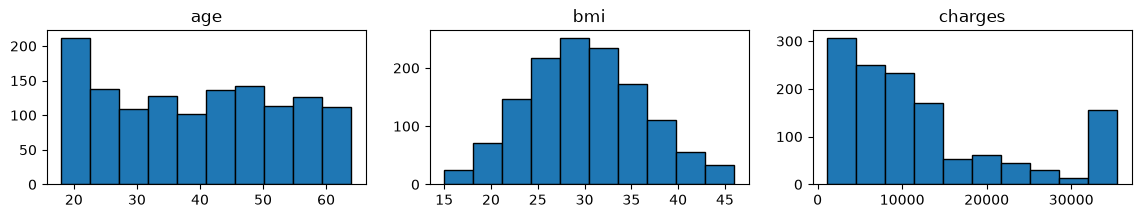

In [54]:
plt.figure(figsize=(14,2))
for i , col in enumerate(num_col):
    plt.subplot(1,3,i+1)
    plt.hist(df[col],edgecolor="black")
    plt.title(col)
plt.show()

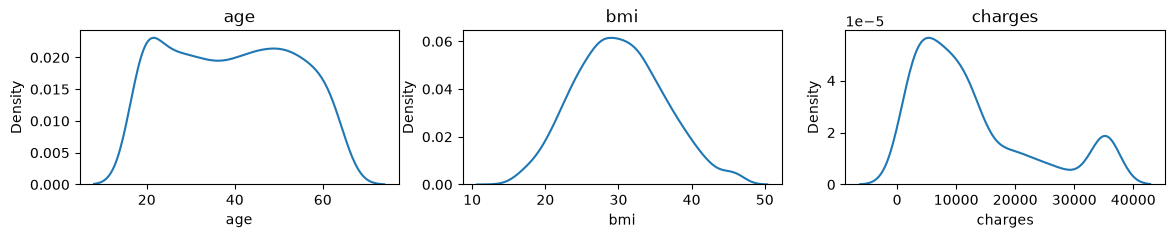

In [55]:
plt.figure(figsize=(14,2))
for i , col in enumerate(num_col):
    plt.subplot(1,3,i+1)
    sns.kdeplot(df[col])
    plt.title(col)
plt.show()

##### categorical distribution

In [56]:
cat_col

['sex', 'smoker', 'region', 'children']

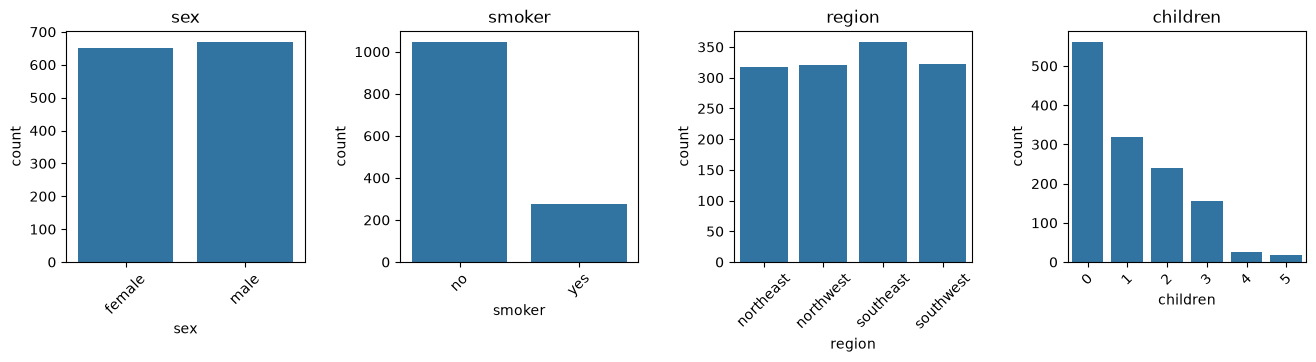

In [57]:
plt.figure(figsize=(16, 3))
for i , col in enumerate(cat_col):
    plt.subplot(1,4,i+1)
    sns.countplot(x = col , data = df)
    plt.title(col)
    plt.xticks(rotation=45)
plt.subplots_adjust(hspace=0.8, wspace=0.4)
plt.show()

In [58]:
df['region'].unique()

['southwest', 'southeast', 'northwest', 'northeast']
Categories (4, str): ['northeast', 'northwest', 'southeast', 'southwest']

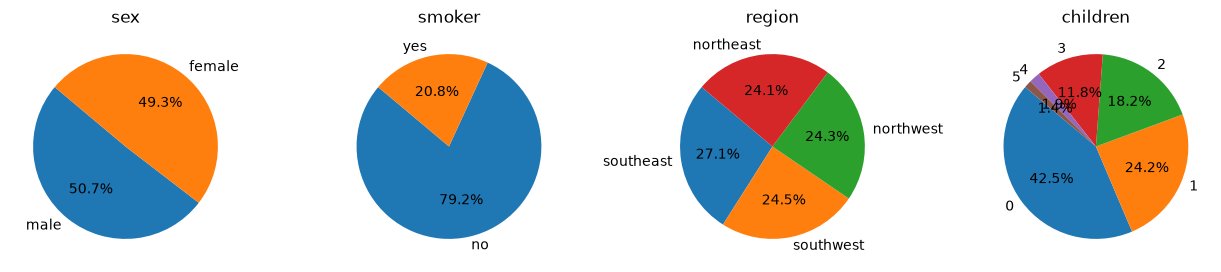

In [59]:
plt.figure(figsize=(16, 3))
for i , col in enumerate(cat_col):
    plt.subplot(1,4,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categorical = unique.index
    plt.pie(count, labels=categorical, autopct='%1.1f%%', startangle=140)
    plt.title(col)
plt.show()

### outliers - graph

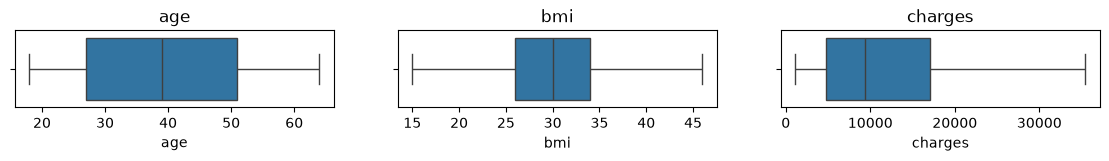

In [60]:
plt.figure(figsize=(14,1))
for i , col in enumerate(num_col):
    plt.subplot(1,3,i+1)
    sns.boxplot(df[col], orient='h')
    plt.title(col)
plt.show()

### relation - graph

#### num : num

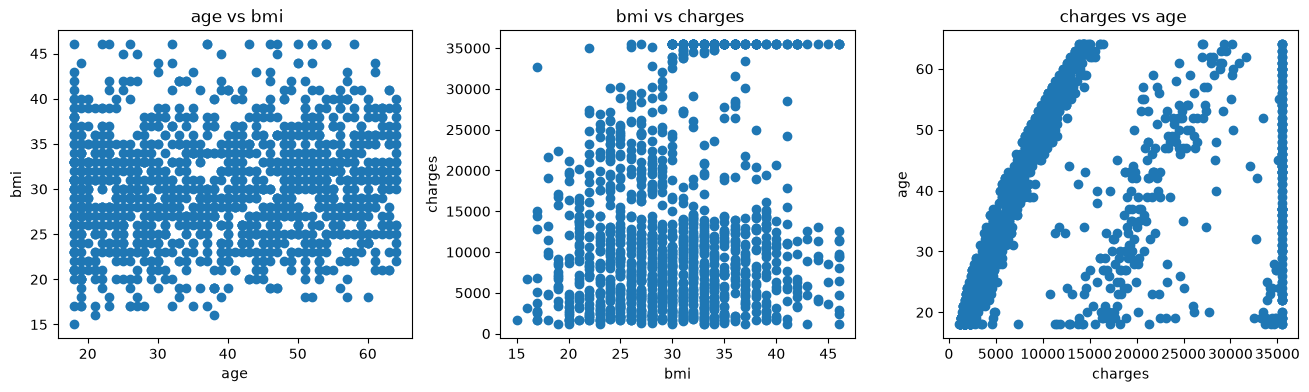

In [61]:
plt.figure(figsize=(16,4))
for i in range(len(num_col)):
    plt.subplot(1,3,i+1)
    if i < 2 :
        plt.scatter(df[num_col[i]],df[num_col[i+1]])
        plt.title(f" {num_col[i]} vs {num_col[i+1]}")
        plt.xlabel(num_col[i])
        plt.ylabel(num_col[i+1])
    else:
        plt.scatter(df[num_col[i]],df[num_col[i-2]])
        plt.title(f" {num_col[i]} vs {num_col[i-2]}")
        plt.xlabel(num_col[i])
        plt.ylabel(num_col[i-2])
plt.subplots_adjust(hspace=0.8,wspace=0.25)


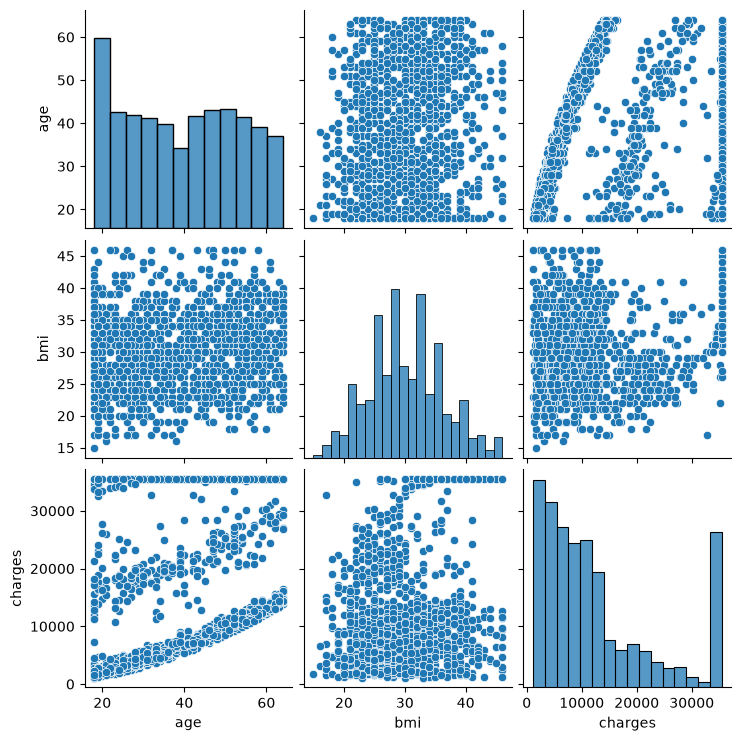

In [62]:
sns.pairplot(df)



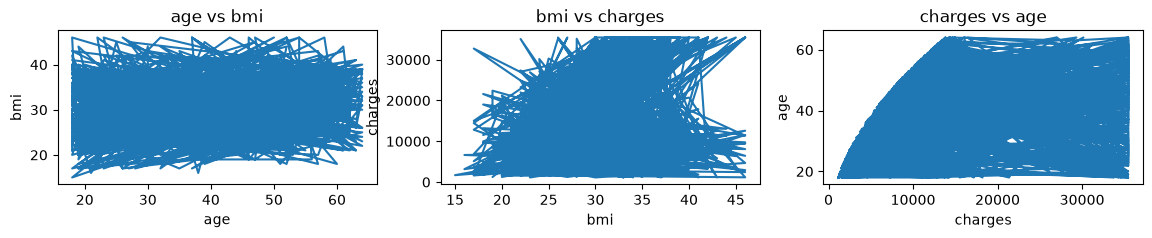

In [63]:
plt.figure(figsize=(14, 2))

for i, col in enumerate(num_col):
    plt.subplot(1, 3, i + 1)

    if i < 2:
        plt.plot(df[num_col[i]], df[num_col[i + 1]])
        plt.title(f"{num_col[i]} vs {num_col[i + 1]}")
        plt.xlabel(num_col[i])
        plt.ylabel(num_col[i + 1])

    else:
        plt.plot(df[num_col[i]], df[num_col[i - 2]])
        plt.title(f"{num_col[i]} vs {num_col[i - 2]}")
        plt.xlabel(num_col[i])
        plt.ylabel(num_col[i - 2])

<Axes: >

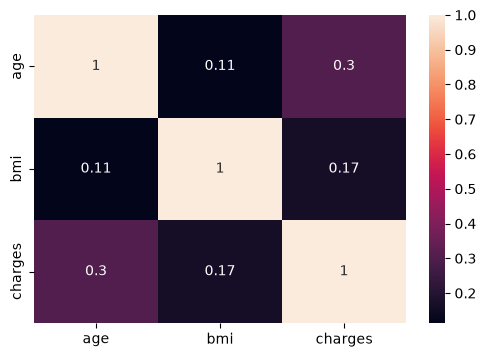

In [64]:
plt.figure(figsize=(6, 4))
corr = df[num_col].corr()
sns.heatmap(corr, annot= True)

In [65]:
print(cat_col)
print(num_col)


['sex', 'smoker', 'region', 'children']
['age', 'bmi', 'charges']


#### num : cat

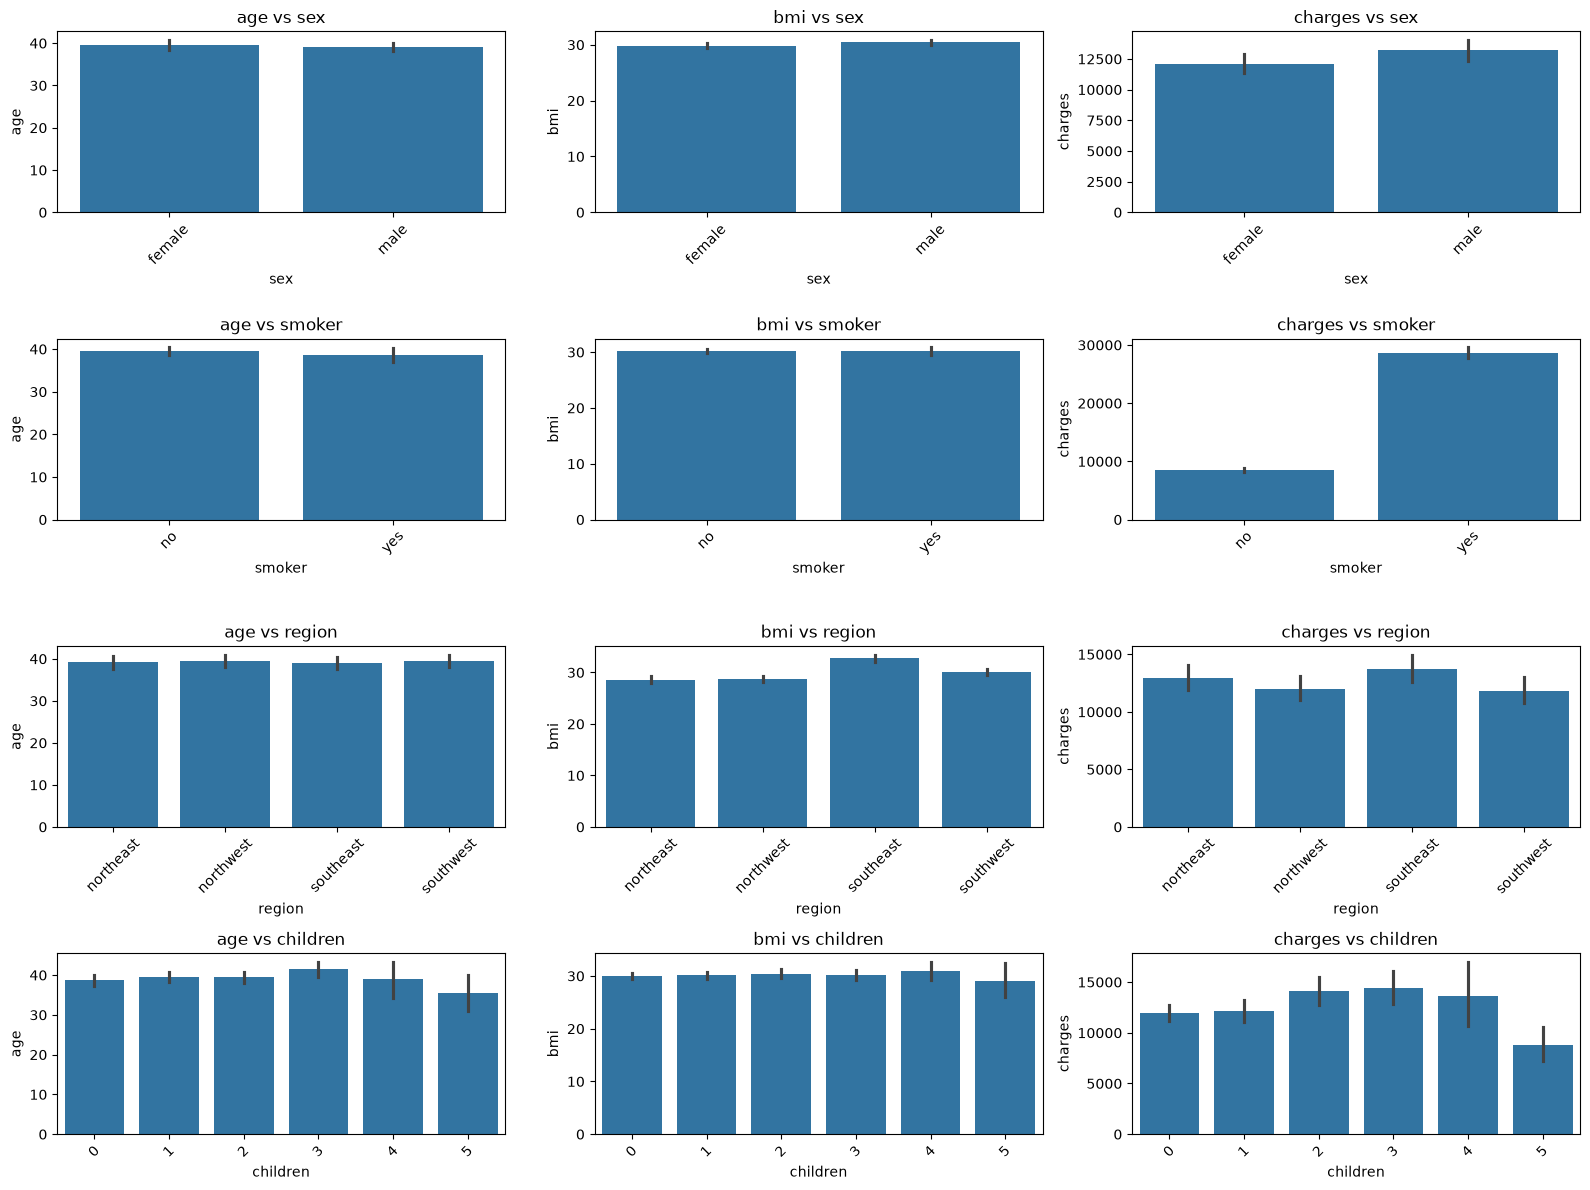

In [66]:
plt.figure(figsize=(16, 12))

for i, col_cat in enumerate(cat_col):
    for j, col_num in enumerate(num_col):
        # chatgpt help me to calc this (i * len(num_col) + j + 1)
        plt.subplot(4, 3, i * len(num_col) + j + 1) 
        sns.barplot(x=col_cat, y=col_num, data=df)
        plt.title(f"{col_num} vs {col_cat}")
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
        

In [67]:
cat_col

['sex', 'smoker', 'region', 'children']

### cat : cat

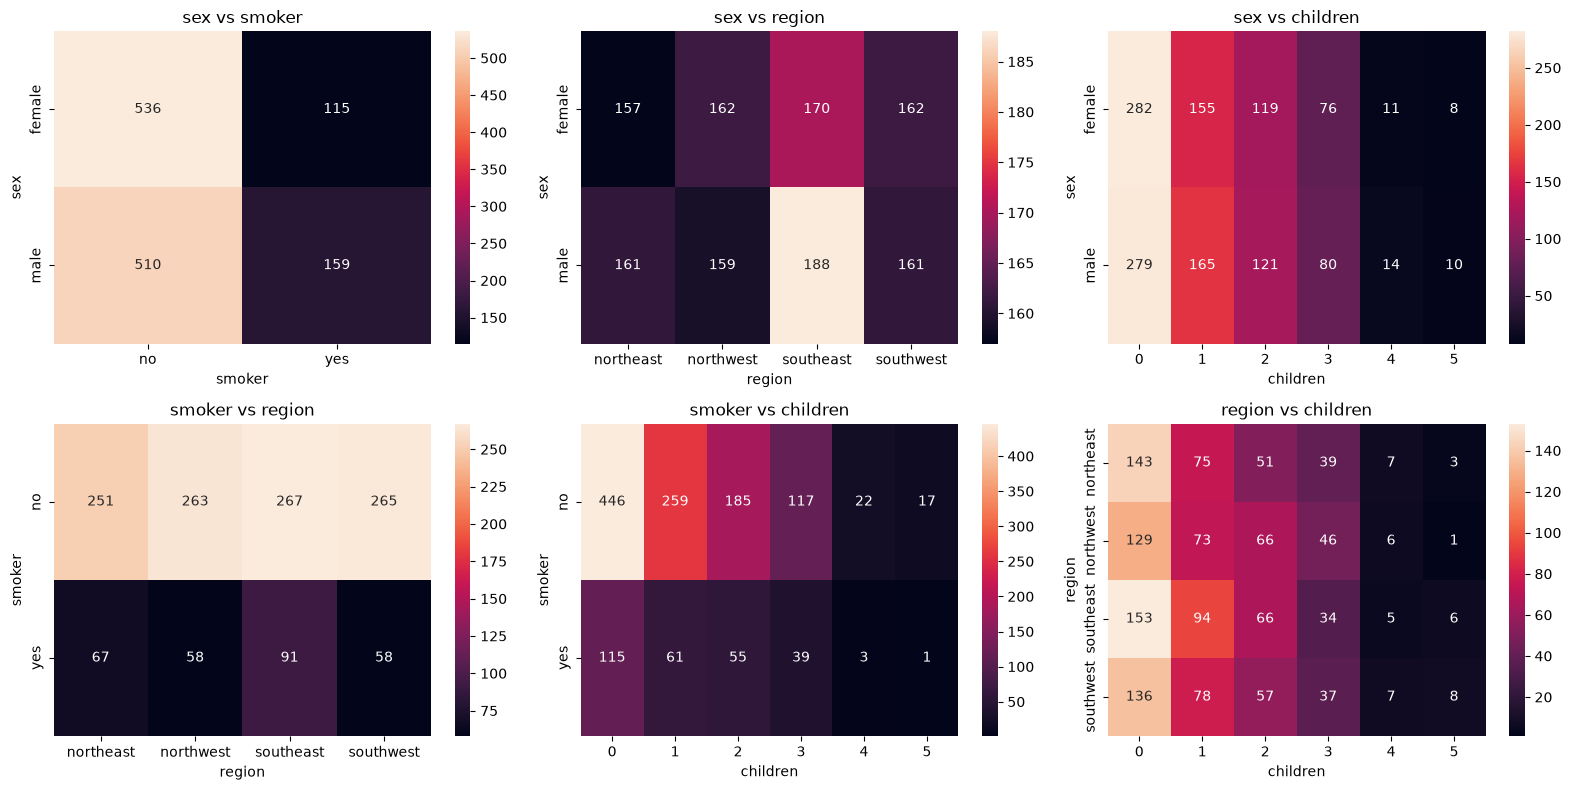

In [68]:
plt.figure(figsize=(16, 8))

k = 1
#   chatgpt help me
for i in range(len(cat_col)):
    for j in range(i + 1, len(cat_col)): 

        plt.subplot(2, 3, k)

        cross = pd.crosstab(df[cat_col[i]], df[cat_col[j]])

        sns.heatmap(cross, annot=True, fmt="d")

        plt.title(f"{cat_col[i]} vs {cat_col[j]}")

        k += 1

plt.tight_layout()
plt.show()